<a href="https://colab.research.google.com/github/dantae74/aice/blob/main/ref/01_%EA%BD%83_%EC%9D%B4%EB%AF%B8%EC%A7%80_%EB%B6%84%EB%A5%98%ED%95%98%EA%B8%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 이미지 실습
# 꽃 이미지 데이터를 가지고 이미지 모델을 만들고 분류

### 학습목차

#### A. 라벨정보 포함한 이미지 데이터셋 만들기
1. 필요한 라이브러리 임포트
2. 이미지 파일 가져오기
3. os.listdir과 PIL.Image 이용하여 이미지 읽기
4. 이미지 라벨링 포함해서 Class별 이미지 리스트 만들기
5. Train/Test 데이터셋 만들기

#### B. Build Model
1. Build Model
2. Callback
3. 모델 학습
4. 성능 그래프
5. Predict

#### C. image_dataset_from_directory 이용하여 데이터셋 만들기
1. 필요한 라이브러리 임포트
2. 이미지 파일 가져오기
3. 이미지 파일 하나 읽어 이미지 보기
4. Data Preprocess : image_dataset_from_directory 이용하여 한번에 처리

#### D. 모델링
1. Build Model : Functional API
2. Callback
3. 모델 학습
4. 성능 그래프
5. Predict

#### E. MobileNet Transfer Learning & Fine-tuning 모델링


In [1]:
import os
from glob import glob
from PIL import Image

import numpy as np
import tensorflow as tf

import matplotlib.pyplot as plt

In [2]:
# 약 3,700장의 꽃 사진 데이터세트를 사용합니다.
# 아래 데이터 가져오기 그냥 사용합니다.

import pathlib
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url, untar=True)
data_dir = pathlib.Path(data_dir) / 'flower_photos'

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [10]:
# 이미지 패스 확인
data_dir

PosixPath('/root/.keras/datasets/flower_photos/flower_photos')

In [11]:
ls -l {data_dir}/

total 624
drwxr-xr-x 2 root root  36864 Feb 10  2016 daisy/
drwxr-xr-x 2 root root  49152 Feb 10  2016 dandelion/
-rw-r----- 1 root root 418049 Feb  9  2016 LICENSE.txt
drwxr-xr-x 2 root root  36864 Feb 10  2016 roses/
drwxr-xr-x 2 root root  36864 Feb 10  2016 sunflowers/
drwxr-xr-x 2 root root  49152 Feb 10  2016 tulips/


In [13]:
# daisy 폴더 안의 이미지 개수 확인
!ls -l {data_dir}/daisy | wc -l

634


## 1. 이미지 읽기 (os.listdir과 PIL.Image)

In [14]:
# 이미지 path
daisy_path = str(data_dir / 'daisy') + '/'
dandelion_path = str(data_dir / 'dandelion') + '/'
roses_path = str(data_dir / 'roses') + '/'
sunflowers_path = str(data_dir / 'sunflowers') + '/'
tulips_path = str(data_dir / 'tulips') + '/'

In [15]:
# 이미지 파일 리스트 만들기
daisy_list = os.listdir(daisy_path)
dandelion_list = os.listdir(dandelion_path)
roses_list = os.listdir(roses_path)
sunflowers_list = os.listdir(sunflowers_path)
tulips_list = os.listdir(tulips_path)

In [16]:
# 이미지 파일 리스트 샘플 보기
daisy_list[:3], roses_list[:3]

(['14551098743_2842e7a004_n.jpg',
  '10993710036_2033222c91.jpg',
  '5765646947_82e95a9cc9_n.jpg'],
 ['410425647_4586667858.jpg',
  '5731750490_ba3325b7ee_n.jpg',
  '9614492283_66020fb4eb_n.jpg'])

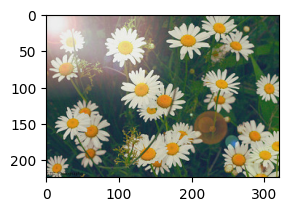

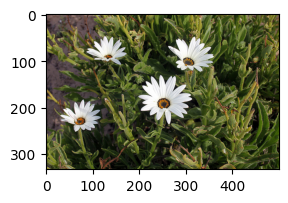

In [18]:
# 샘플 이미지 출력하기
for img_file in daisy_list[:2]:
    img = Image.open(daisy_path + img_file)
    plt.figure(figsize=(3, 3)) # Set a smaller figure size
    plt.imshow(img)
    plt.show()

## 2. 이미지 라벨링 및 이미지 리스트 만들기

In [19]:
class2idx = {'daisy': 0, 'dandelion': 1, 'roses': 2, 'sunflowers': 3, 'tulips': 4}
idx2class = {0: 'daisy', 1: 'dandelion', 2: 'roses', 3: 'sunflowers', 4: 'tulips'}

In [24]:
# 이미지 리스트 및 라벨 리스트 만들기
img_list = []
label_list = []

for img_file in daisy_list:
    img = Image.open(daisy_path + img_file).resize((128, 128))
    img_list.append(img)
    label_list.append(class2idx['daisy'])

for img_file in dandelion_list:
    img = Image.open(dandelion_path + img_file).resize((128, 128))
    img_list.append(img)
    label_list.append(class2idx['dandelion'])

for img_file in roses_list:
    img = Image.open(roses_path + img_file).resize((128, 128))
    img_list.append(img)
    label_list.append(class2idx['roses'])

for img_file in sunflowers_list:
    img = Image.open(sunflowers_path + img_file).resize((128, 128))
    img_list.append(img)
    label_list.append(class2idx['sunflowers'])

for img_file in tulips_list:
    img = Image.open(tulips_path + img_file).resize((128, 128))
    img_list.append(img)
    label_list.append(class2idx['tulips'])


In [26]:
# img_list에 있는 이미지들의 크기(size) 확인

print(f"Total number of images in img_list: {len(img_list)}")
print("Sizes of the first 5 images:")
for i, img in enumerate(img_list[:5]):
    print(f"  Image {i+1} size: {img.size}")

Total number of images in img_list: 3670
Sizes of the first 5 images:
  Image 1 size: (128, 128)
  Image 2 size: (128, 128)
  Image 3 size: (128, 128)
  Image 4 size: (128, 128)
  Image 5 size: (128, 128)


In [27]:
# 이미지 리스트 및 라벨 리스트를 numpy arrray로 변경
img_list_arr = np.array(img_list)
label_list_arr = np.array(label_list)

In [28]:
# 이미지 array와 라벨 array shape 확인
print(f"Image array shape: {img_list_arr.shape}")
print(f"Label array shape: {label_list_arr.shape}")

Image array shape: (3670, 128, 128, 3)
Label array shape: (3670,)


## Train / Test / Validation 데이터셋 만들기